<div align="center">

# <span style="color: #3498db;">CA2 - Genetic & Game</span>

**<span style="color:rgb(247, 169, 0);">[Mahdi Zandevakili]</span> - <span style="color:rgb(143, 95, 195);">[810103327]</span>**

</div>


<div style="font-family: Arial, sans-serif; line-height: 1.6;">

### 📊 Matplotlib – Data Visualization in Python  

matplotlib is a python library that is mainly used for data visualization. This library allows you to plot different type of figures including scatters and histograms. In the first part of this project you are supposed to implement a genetic algorithm. To visualize plots that are required in the project description use plotting as much as you can because it gives a great insight on what is happening during each run. It also helps you to compare your results whenevever you want to understand effect of different parameters during different runs.
For more information, check [this notebook](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/04.00-Introduction-To-Matplotlib.ipynb) and visit [the website](https://matplotlib.org/stable/tutorials/pyplot.html#sphx-glr-tutorials-pyplot-py).

In [ ]:
import matplotlib.pyplot as plt

# <span style="color: #3498db;">Genetic Algorithm</span>

In [2]:
import random
import itertools
import numpy as np

In [3]:
# algorithm parameters
numCoeffs = 41
populationSize = 100
generations = 200
mutationRate = 0.15
functionRange = (-np.pi, np.pi)
sampleCount = 100
A = 10

In [4]:
def getTargetFunction(functionName="sin_cos"):
    def sinCosFunction(t):
        return np.sin(2 * np.pi * t) + 0.5 * np.cos(4 * np.pi * t)

    def linearFunction(t):
        return 2 * t + 1

    def quadraticFunction(t):
        return 4 * (t**2) - 4 * t + 2

    def cubicFunction(t):
        return 8 * (t**3) - 12 * (t**2) + 6 * t

    def gaussianFunction(t):
        mu = 0.5
        sigma = 0.1
        return np.exp(-((t - mu) ** 2) / (2 * sigma**2))

    def squareWaveFunction(t):
        return 0.5 * (np.sign(np.sin(2 * np.pi * t)) + 1)

    def sawtoothFunction(t):
        return (t * 5) % 1

    def complexFourierFunction(t):
        return (
            np.sin(2 * np.pi * t)
            + 0.3 * np.cos(4 * np.pi * t)
            + 0.2 * np.sin(6 * np.pi * t)
            + 0.1 * np.cos(8 * np.pi * t)
        )

    def polynomialFunction(t):
        return 10 * (t**5) - 20 * (t**4) + 15 * (t**3) - 4 * (t**2) + t + 0.5

    functionOptions = {
        "sin_cos": sinCosFunction,
        "linear": linearFunction,
        "quadratic": quadraticFunction,
        "cubic": cubicFunction,
        "gaussian": gaussianFunction,
        "square_wave": squareWaveFunction,
        "sawtooth": sawtoothFunction,
        "complex_fourier": complexFourierFunction,
        "polynomial": polynomialFunction,
    }

    selectedFunction = functionOptions.get(functionName.lower())
    if selectedFunction:
        return selectedFunction

In [5]:
# generate samples
tSamples = np.linspace(functionRange[0], functionRange[1], sampleCount)
fSamples = getTargetFunction()(tSamples)

<div style="color:rgb(235, 66, 32); font-weight: bold;">⚠️ Important Note:</div>  

Using **NumPy arrays** allows you to perform operations on vectors **more efficiently** and **faster**.

**Avoid using `for` loops** whenever possible, as vectorized operations in NumPy are **optimized for performance** and significantly reduce execution time.  


Generation 1: RMSE = 22.3598, MAE = 17.8957, R2 = -815.0259
Generation 2: RMSE = 20.5511, MAE = 16.5075, R2 = -688.3481
Generation 3: RMSE = 20.4417, MAE = 16.8296, R2 = -681.0259
Generation 4: RMSE = 19.5496, MAE = 15.9612, R2 = -622.7964
Generation 5: RMSE = 18.5801, MAE = 15.4615, R2 = -562.4626
Generation 6: RMSE = 18.3664, MAE = 14.6222, R2 = -549.5757
Generation 7: RMSE = 17.2893, MAE = 13.0848, R2 = -486.8896
Generation 8: RMSE = 16.7912, MAE = 13.4050, R2 = -459.1854
Generation 9: RMSE = 16.2836, MAE = 12.7029, R2 = -431.7811
Generation 10: RMSE = 15.5537, MAE = 12.4309, R2 = -393.8520
Generation 11: RMSE = 14.5044, MAE = 12.4420, R2 = -342.3730
Generation 12: RMSE = 13.8979, MAE = 11.3214, R2 = -314.2607
Generation 13: RMSE = 13.1574, MAE = 10.6649, R2 = -281.5605
Generation 14: RMSE = 12.4618, MAE = 9.4873, R2 = -252.4707
Generation 15: RMSE = 11.8140, MAE = 9.7008, R2 = -226.8039
Generation 16: RMSE = 11.6024, MAE = 9.6827, R2 = -218.7172
Generation 17: RMSE = 11.4533, MAE =

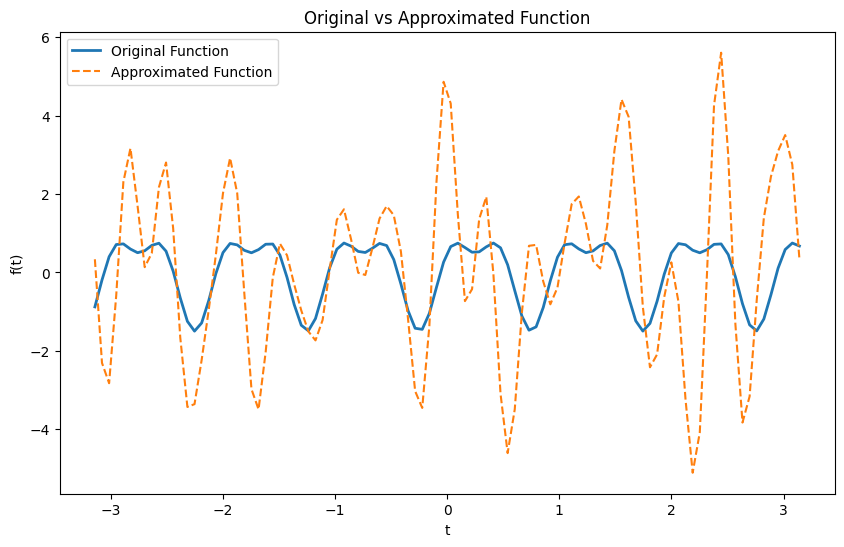

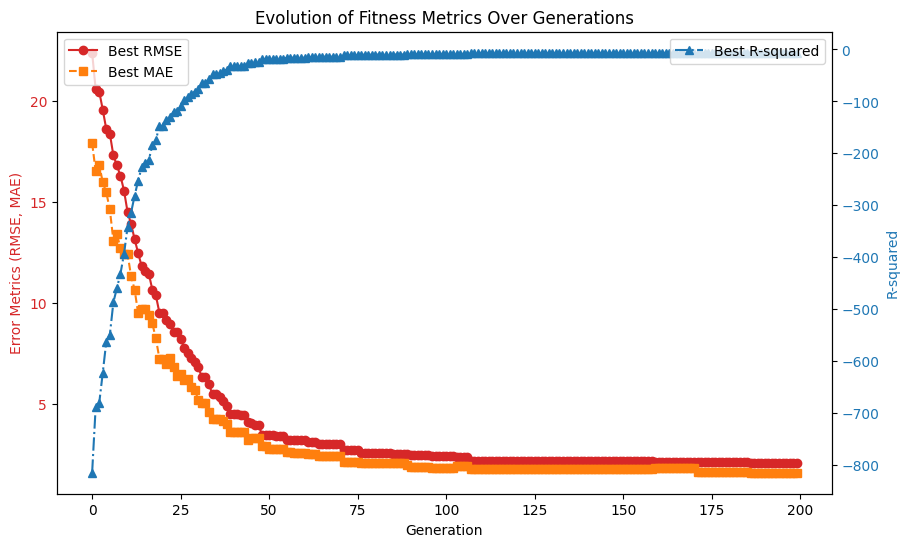

In [6]:
#TODO: Implement the rest of the algorithm
def compute_fourier_series(chromosome, t):
    a0 = chromosome[0]
    a_coeffs = chromosome[1:21]
    b_coeffs = chromosome[21:]
    harmonics = np.arange(1, 21)
    # (20, len(t)) array
    cos_terms = np.cos(np.outer(harmonics, t))
    sin_terms = np.sin(np.outer(harmonics, t))
    y = a0 + np.dot(a_coeffs, cos_terms) + np.dot(b_coeffs, sin_terms)
    return y

def evaluate_fitness(chromosome):
    predicted_y = compute_fourier_series(chromosome, tSamples)
    error = np.sqrt(np.mean((predicted_y - fSamples) ** 2))
    return -error

def generate_initial_population():
    return [np.random.uniform(-A, A, numCoeffs) for _ in range(populationSize)]

def tournament_selection(population):
    tournament_size = 3
    selected_individuals = []
    for _ in range(populationSize):
        contenders = random.sample(population, tournament_size)
        fitness_scores = [evaluate_fitness(ind) for ind in contenders]
        winner = contenders[np.argmax(fitness_scores)]
        selected_individuals.append(winner)
    return selected_individuals

def perform_crossover(parent1, parent2):
    crossover_point = random.randint(1, numCoeffs - 1)
    offspring1 = np.concatenate((parent1[:crossover_point], parent2[crossover_point:]))
    offspring2 = np.concatenate((parent2[:crossover_point], parent1[crossover_point:]))
    return offspring1, offspring2

def apply_mutation(chromosome):
    for i in range(numCoeffs):
        if random.random() < mutationRate:
            chromosome[i] += np.random.normal(0, 1)
            chromosome[i] = np.clip(chromosome[i], -A, A)
    return chromosome

population = generate_initial_population()

def generate_next_population(current_population):
    selected = tournament_selection(current_population)
    new_population = []
    random.shuffle(selected)
    for i in range(0, populationSize - 1, 2):
        parent1 = selected[i]
        parent2 = selected[i + 1]
        child1, child2 = perform_crossover(parent1, parent2)
        new_population.append(apply_mutation(child1))
        new_population.append(apply_mutation(child2))
    if len(new_population) < populationSize:
        new_population.append(apply_mutation(selected[-1]))
    # keep the best from the current generation
    fitness_scores = [evaluate_fitness(ind) for ind in current_population]
    best_idx = np.argmax(fitness_scores)
    best_individual = current_population[best_idx]
    new_population[0] = best_individual.copy()
    return new_population

def evaluate_fitness_mae(chromosome):
    predicted_y = compute_fourier_series(chromosome, tSamples)
    mae = np.mean(np.abs(predicted_y - fSamples))
    return -mae

def evaluate_fitness_r2(chromosome):
    predicted_y = compute_fourier_series(chromosome, tSamples)
    ss_res = np.sum((fSamples - predicted_y) ** 2)
    ss_tot = np.sum((fSamples - np.mean(fSamples)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return r2


best_rmse_records = []
best_mae_records = []
best_r2_records = []

# The main loop
for generation in range(generations):
    fitness_scores = [evaluate_fitness(ind) for ind in population]
    best_idx = np.argmax(fitness_scores)
    best_individual = population[best_idx]


    best_rmse = -evaluate_fitness(best_individual)
    best_mae = -evaluate_fitness_mae(best_individual)
    best_r2 = evaluate_fitness_r2(best_individual)

    best_rmse_records.append(best_rmse)
    best_mae_records.append(best_mae)
    best_r2_records.append(best_r2)

    print(f"Generation {generation + 1}: RMSE = {best_rmse:.4f}, MAE = {best_mae:.4f}, R2 = {best_r2:.4f}")

    population = generate_next_population(population)


best_idx = np.argmax([evaluate_fitness(ind) for ind in population])
best_chromosome = population[best_idx]
approximated_y = compute_fourier_series(best_chromosome, tSamples)

final_rmse = -evaluate_fitness(best_chromosome)
final_mae = -evaluate_fitness_mae(best_chromosome)
final_r2 = evaluate_fitness_r2(best_chromosome)

print("\nFinal Best Individual Metrics:")
print(f"RMSE: {final_rmse:.4f}")
print(f"MAE: {final_mae:.4f}")
print(f"R-squared: {final_r2:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(tSamples, fSamples, label="Original Function", linewidth=2)
plt.plot(tSamples, approximated_y, label="Approximated Function", linestyle="--")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Original vs Approximated Function")
plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Generation')
ax1.set_ylabel('Error Metrics (RMSE, MAE)', color=color)
ax1.plot(best_rmse_records, marker='o', linestyle='-', color='tab:red', label='Best RMSE')
ax1.plot(best_mae_records, marker='s', linestyle='--', color='tab:orange', label='Best MAE')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('R-squared', color=color)
ax2.plot(best_r2_records, marker='^', linestyle='-.', color=color, label='Best R-squared')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title("Evolution of Fitness Metrics Over Generations")
plt.show()


# <span style="color: #3498db;">Minmax Algorithm</span>

In [7]:
import random
import numpy as np
from math import inf
import time
import pygame

pygame 2.6.1 (SDL 2.28.4, Python 3.13.3)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [8]:
class PentagoGame:
    def __init__(self, ui=False, print_game=False, depth=2):
        self.board = np.zeros((6, 6), dtype=int)
        self.current_player = 1
        self.ui = ui
        self.depth = depth
        self.nodes_visited = 0
        self.game_over = False
        self.result = None
        self.selected_block = None
        self.move_stage = 0
        self.temp_piece = None
        self.print_game = print_game  # renamed from self.print

        if ui:
            pygame.init()
            self.screen = pygame.display.set_mode((800, 600))
            pygame.display.set_caption("Pygame Board")
            self.font = pygame.font.Font(None, 36)
            self.show_buttons = False
            self.buttons = {
                "rotate_cw": pygame.Rect(650, 200, 100, 50),
                "rotate_ccw": pygame.Rect(650, 300, 100, 50),
            }
            self.setup_controls()
            self.draw_board()

    def setup_controls(self):
        # Add your control setup if needed
        pass

    def hide_rotation_buttons(self):
        self.show_buttons = False

    def show_rotation_buttons(self):
        self.show_buttons = True

    def copy_board(self, board):
        return np.copy(board)

    def rotate_block(self, board, block, direction):
        row_start = (block // 2) * 3
        col_start = (block % 2) * 3
        sub = board[row_start: row_start + 3, col_start: col_start + 3]
        rotated = np.rot90(sub, 3 if direction == "cw" else 1)
        board[row_start: row_start + 3, col_start: col_start + 3] = rotated

    def get_possible_moves(self, board, player):
        moves = []
        for i in range(6):
            for j in range(6):
                if board[i][j] == 0:
                    for block in range(4):
                        for direction in ["cw", "ccw"]:
                            moves.append((i, j, block, direction))
        return moves

    def apply_move(self, board, move, player):
        new_board = self.copy_board(board)
        row, col, block, direction = move
        if new_board[row][col] != 0:
            return None
        new_board[row][col] = player
        self.rotate_block(new_board, block, direction)
        return new_board

    def check_winner(self, board):
        directions = [(0, 1), (1, 0), (1, 1), (1, -1)]
        for i in range(6):
            for j in range(6):
                if board[i][j] == 0:
                    continue
                for dx, dy in directions:
                    if 0 <= i + 4 * dx < 6 and 0 <= j + 4 * dy < 6:
                        if all(board[i + k * dx][j + k * dy] == board[i][j] for k in range(5)):
                            return board[i][j]
        if np.all(board != 0):
            return 0  # draw
        return None

    def score_line(self, line, player):
        score = 0
        count = 0
        for cell in line:
            if cell == player:
                count += 1
            else:
                if count > 0:
                    if count == 1:
                        score += 1
                    elif count == 2:
                        score += 10
                    elif count == 3:
                        score += 50
                    elif count == 4:
                        score += 200
                    count = 0
        if count > 0:
            if count == 1:
                score += 1
            elif count == 2:
                score += 10
            elif count == 3:
                score += 50
            elif count == 4:
                score += 200
        return score

    def evaluate_board(self, board):
        winner = self.check_winner(board)
        if winner is not None:
            return 10000 * winner

        score = 0
        for player in [1, -1]:
            multiplier = 1 if player == 1 else -1
            for row in board:
                score += multiplier * self.score_line(row, player)
            for col in board.T:
                score += multiplier * self.score_line(col, player)
            for i in range(-5, 5):
                diag = np.diag(board, k=i)
                score += multiplier * self.score_line(diag, player)
                anti_diag = np.diag(np.fliplr(board), k=i)
                score += multiplier * self.score_line(anti_diag, player)
        return score

    def evaluate_consecutive(self, count):
        if count >= 5:
            return 10000
        return [0, 1, 10, 100, 1000][count]

    def minimax_search(self, board, depth, alpha, beta, maximizingPlayer):
        self.nodes_visited += 1
        winner = self.check_winner(board)
        if depth == 0 or winner is not None:
            return self.evaluate_board(board)

        if maximizingPlayer:
            maxEval = -inf
            moves = self.get_possible_moves(board, 1)
            for move in moves:
                new_board = self.apply_move(board, move, 1)
                if new_board is None:
                    continue
                eval_value = self.minimax_search(new_board, depth - 1, alpha, beta, False)
                maxEval = max(maxEval, eval_value)
                alpha = max(alpha, eval_value)
                if beta <= alpha:
                    break
            return maxEval
        else:
            minEval = inf
            moves = self.get_possible_moves(board, -1)
            for move in moves:
                new_board = self.apply_move(board, move, -1)
                if new_board is None:
                    continue
                eval_value = self.minimax_search(new_board, depth - 1, alpha, beta, True)
                minEval = min(minEval, eval_value)
                beta = min(beta, eval_value)
                if beta <= alpha:
                    break
            return minEval

    def minimax(self):
        return self.minimax_search(self.board, self.depth, -inf, inf, self.current_player == 1)

    def get_computer_move(self):
        start_time = time.time()
        best_move = None
        best_value = inf
        moves = self.get_possible_moves(self.board, -1)
        if not moves:
            return None

        for move in moves:
            if self.game_over:
                break
            new_board = self.apply_move(self.board, move, -1)
            if new_board is None:
                continue

            try:
                value = self.minimax_search(new_board, self.depth - 1, -inf, inf, False)
            except Exception as e:
                print("Minimax exception:", e)
                value = inf

            if value < best_value:
                best_value = value
                best_move = move

        if self.print_game:
            print(f"Move took {time.time() - start_time:.2f}s, nodes visited: {self.nodes_visited}")
        self.nodes_visited = 0
        return best_move

    def draw_text(self, text, center_pos, max_width):
        font_size = 24
        font = pygame.font.Font(None, font_size)
        text_surface = font.render(text, True, (0, 0, 0))
        text_width = text_surface.get_width()
        if text_width > max_width:
            scale_factor = max_width / text_width
            new_font_size = int(font_size * scale_factor)
            font = pygame.font.Font(None, new_font_size)
            text_surface = font.render(text, True, (0, 0, 0))
        text_rect = text_surface.get_rect(center=center_pos)
        self.screen.blit(text_surface, text_rect)

    def draw_board(self):
        self.screen.fill((0, 0, 0))
        for i in range(6):
            for j in range(6):
                x0 = j * 100
                y0 = i * 100
                if self.board[i][j] == 1:
                    pygame.draw.circle(self.screen, (255, 0, 0), (x0 + 50, y0 + 50), 40)
                elif self.board[i][j] == -1:
                    pygame.draw.circle(self.screen, (0, 0, 255), (x0 + 50, y0 + 50), 40)
                pygame.draw.rect(self.screen, (255, 255, 255), (x0, y0, 100, 100), 1)

        # Draw bold lines for quadrants
        for i in [3, 6]:
            pygame.draw.line(self.screen, (255, 255, 255), (0, i * 100), (600, i * 100), 3)
            pygame.draw.line(self.screen, (255, 255, 255), (i * 100, 0), (i * 100, 600), 3)

        if self.move_stage == 2:
            self.highlight_selected_block()
            self.show_rotation_buttons()

        if self.show_buttons:
            pygame.draw.rect(self.screen, (144, 238, 144), self.buttons["rotate_cw"])
            pygame.draw.rect(self.screen, (173, 216, 230), self.buttons["rotate_ccw"])
            self.draw_text("CLOCKWISE", self.buttons["rotate_cw"].center, 100)
            self.draw_text("COUNTER-CLOCKWISE", self.buttons["rotate_ccw"].center, 100)

    def click_handler(self, event):
        if self.game_over or self.current_player != 1:
            return

        x, y = event.pos
        if self.move_stage == 0:
            if x > 600:
                return
            col = x // 100
            row = y // 100
            if 0 <= row < 6 and 0 <= col < 6 and self.board[row][col] == 0:
                self.temp_piece = (row, col)
                self.board[row][col] = 1
                self.move_stage = 1
                self.draw_board()

        elif self.move_stage == 1:
            if x > 600:
                return
            block_x = 0 if x < 300 else 1
            block_y = 0 if y < 300 else 1
            self.selected_block = block_y * 2 + block_x
            self.move_stage = 2
            self.show_rotation_buttons()
            self.highlight_selected_block()

        elif self.move_stage == 2:
            if self.buttons["rotate_cw"].collidepoint(event.pos):
                self.apply_rotation("cw")
            elif self.buttons["rotate_ccw"].collidepoint(event.pos):
                self.apply_rotation("ccw")

    def apply_rotation(self, direction):
        self.rotate_block(self.board, self.selected_block, direction)
        self.current_player = -1
        self.move_stage = 0
        self.selected_block = None
        self.temp_piece = None
        self.hide_rotation_buttons()
        self.draw_board()
        pygame.display.flip()
        self.check_game_over()
        pygame.time.delay(1000)
        self.play_computer_move()

    def highlight_selected_block(self):
        colors = [(255, 153, 153), (153, 255, 153), (153, 153, 255), (255, 255, 153)]
        row_start = (self.selected_block // 2) * 3
        col_start = (self.selected_block % 2) * 3
        pygame.draw.rect(self.screen, colors[self.selected_block],
                         (col_start * 100, row_start * 100, 300, 300), 5)

    def play_computer_move(self):
        move = self.get_computer_move()
        if move and not self.game_over:
            new_board = self.apply_move(self.board, move, -1)
            if new_board is not None:
                self.board = new_board
                self.current_player = 1
                self.draw_board()
                pygame.display.flip()
                self.check_game_over()
            else:
                print("Invalid computer move!")

    def check_game_over(self):
        winner = self.check_winner(self.board)
        if winner is not None:
            self.game_over = True
            self.result = winner
            print("Game over! Result:", winner)
            if self.ui:
                self.show_game_over_message()

    def show_game_over_message(self):
        self.screen.fill((200, 200, 200))
        pygame.draw.rect(self.screen, (255, 255, 255), (100, 200, 500, 200))
        pygame.draw.rect(self.screen, (0, 0, 0), (100, 200, 500, 200), 3)
        result_text = f"Player {self.result} wins!" if self.result != 0 else "Draw!"
        text_surface = self.font.render(result_text, True, (255, 0, 0))
        self.screen.blit(text_surface, (250, 250))
        exit_text = self.font.render("Click anywhere to exit", True, (0, 0, 0))
        self.screen.blit(exit_text, (230, 350))
        pygame.display.flip()

    def play(self):
        if self.ui:
            running = True
            while running:
                for event in pygame.event.get():
                    if event.type == pygame.QUIT:
                        running = False
                    elif event.type == pygame.MOUSEBUTTONDOWN:
                        if self.game_over:
                            # If game over, exit on click
                            running = False
                        else:
                            self.click_handler(event)
                self.draw_board()
                pygame.display.flip()
                # If game over, auto-terminate after a delay
                if self.game_over:
                    pygame.time.delay(2000)
                    running = False
            pygame.quit()
            return self.result
        else:
            # Non-UI mode loop remains the same
            while not self.game_over:
                self.print_board()
                winner = self.check_winner(self.board)
                if winner is not None:
                    self.game_over = True  # update game_over so the loop stops
                    return winner

                if self.current_player == 1:
                    moves = self.get_possible_moves(self.board, 1)
                    if not moves:
                        break
                    move = random.choice(moves)
                else:
                    move = self.get_computer_move()
                    if move is None:
                        break

                new_board = self.apply_move(self.board, move, self.current_player)
                if new_board is not None:
                    self.board = new_board
                    self.current_player *= -1
                else:
                    print("Received an invalid move!")
            return self.result

    def print_board(self):
        if not self.print_game:
            return
        print("-" * 25)
        for row in self.board:
            print(" ".join(f"{x:2}" for x in row))
        print("-" * 25)

In [9]:
if __name__ == "__main__":
    numGames = 6
    numWins, numTies, numLosses = 0, 0, 0
    for i in range(numGames):
        game = PentagoGame(ui=False, print_game=True, depth=2)
        result = game.play()
        if result == -1:
            numWins += 1
        elif result == 0:
            numTies += 1
        else:
            numLosses += 1

    print(f"{numWins} wins, {numTies} ties, {numLosses} losses")

-------------------------
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
-------------------------
-------------------------
 0  0  0  0  0  0
 0  0  1  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
-------------------------
Move took 12.09s, nodes visited: 76440
-------------------------
 0  0 -1  0  0  0
 0  0  0  0  0  0
 0  1  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
-------------------------
-------------------------
 0  0 -1  0  0  0
 0  0  0  0  0  0
 0  1  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  1  0  0  0
-------------------------
Move took 10.89s, nodes visited: 67848
-------------------------
 0  0 -1  0  0  0
 1  0  0  0  0  0
 0  0 -1  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  1  0  0  0
-------------------------
-------------------------
 0  0 -1  0  0  0
 1  0  0  0  0  1
 0  0 -1  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0 

KeyboardInterrupt: 